# ДЗ 2. Схема даних для ML-сценарію: E-commerce churn

**Студентка:** Samoilenko Mariia

**Сценарій.** Інтернет-магазин хоче прогнозувати відтік клієнтів. У момент `prediction_ts` модель отримує ознаки клієнта
(активність за останні 30/90 днів) і прогнозує `churn_in_horizon` — чи **не** зробить клієнт жодного оплаченого
замовлення протягом наступних 30 днів (`label_horizon_end = prediction_ts + 30 днів`).

**Структура notebook**
1. ER-діаграма (бізнесові сутності, offline- та online-рівні feature store)
2. DDL у PostgreSQL 16
3. Нормалізація та свідома денормалізація
4. Point-in-Time correctness: історичні ознаки, AS-OF запити, training-data join, контроль інтервалів
5. Online-рівень: матеріалізація з offline-джерела
6. Reflection

## 0. Середовище: PostgreSQL 16 через `pgserver` + `jupysql`

In [ ]:
%pip install -q pgserver jupysql "psycopg[binary]"

In [ ]:
import os

import pgserver
from sqlalchemy import create_engine, text

# Локальний сервер PostgreSQL 16 усередині notebook; дані зберігаються в ./pgdata
pg = pgserver.get_server(os.path.abspath("pgdata"))
engine = create_engine(pg.get_uri())

with engine.connect() as conn:
    print(conn.execute(text("SELECT version()")).scalar())

%load_ext sql
%sql engine
%config SqlMagic.displaylimit = 50
%config SqlMagic.displaycon = False

## Завдання 1. ER-діаграма

Діаграму побудовано в Graphviz (текстовий DSL `er/er_diagram.dot` у репозиторії; зображення — `er/er_diagram.png`, `er/er_diagram.svg`).

- **Синій блок** — бізнесові сутності (OLTP, 3НФ); фіолетова таблиця — bridge-таблиця N:M.
- **Жовтий блок** — offline-рівень feature store: історія ознак із `valid_from / valid_to` і training events.
- **Зелений блок** — online-рівень: один денормалізований рядок поточних ознак на клієнта.
- Суцільні лінії — FOREIGN KEY; пунктирні — логічні зв'язки без FK (AS-OF JOIN і матеріалізація).

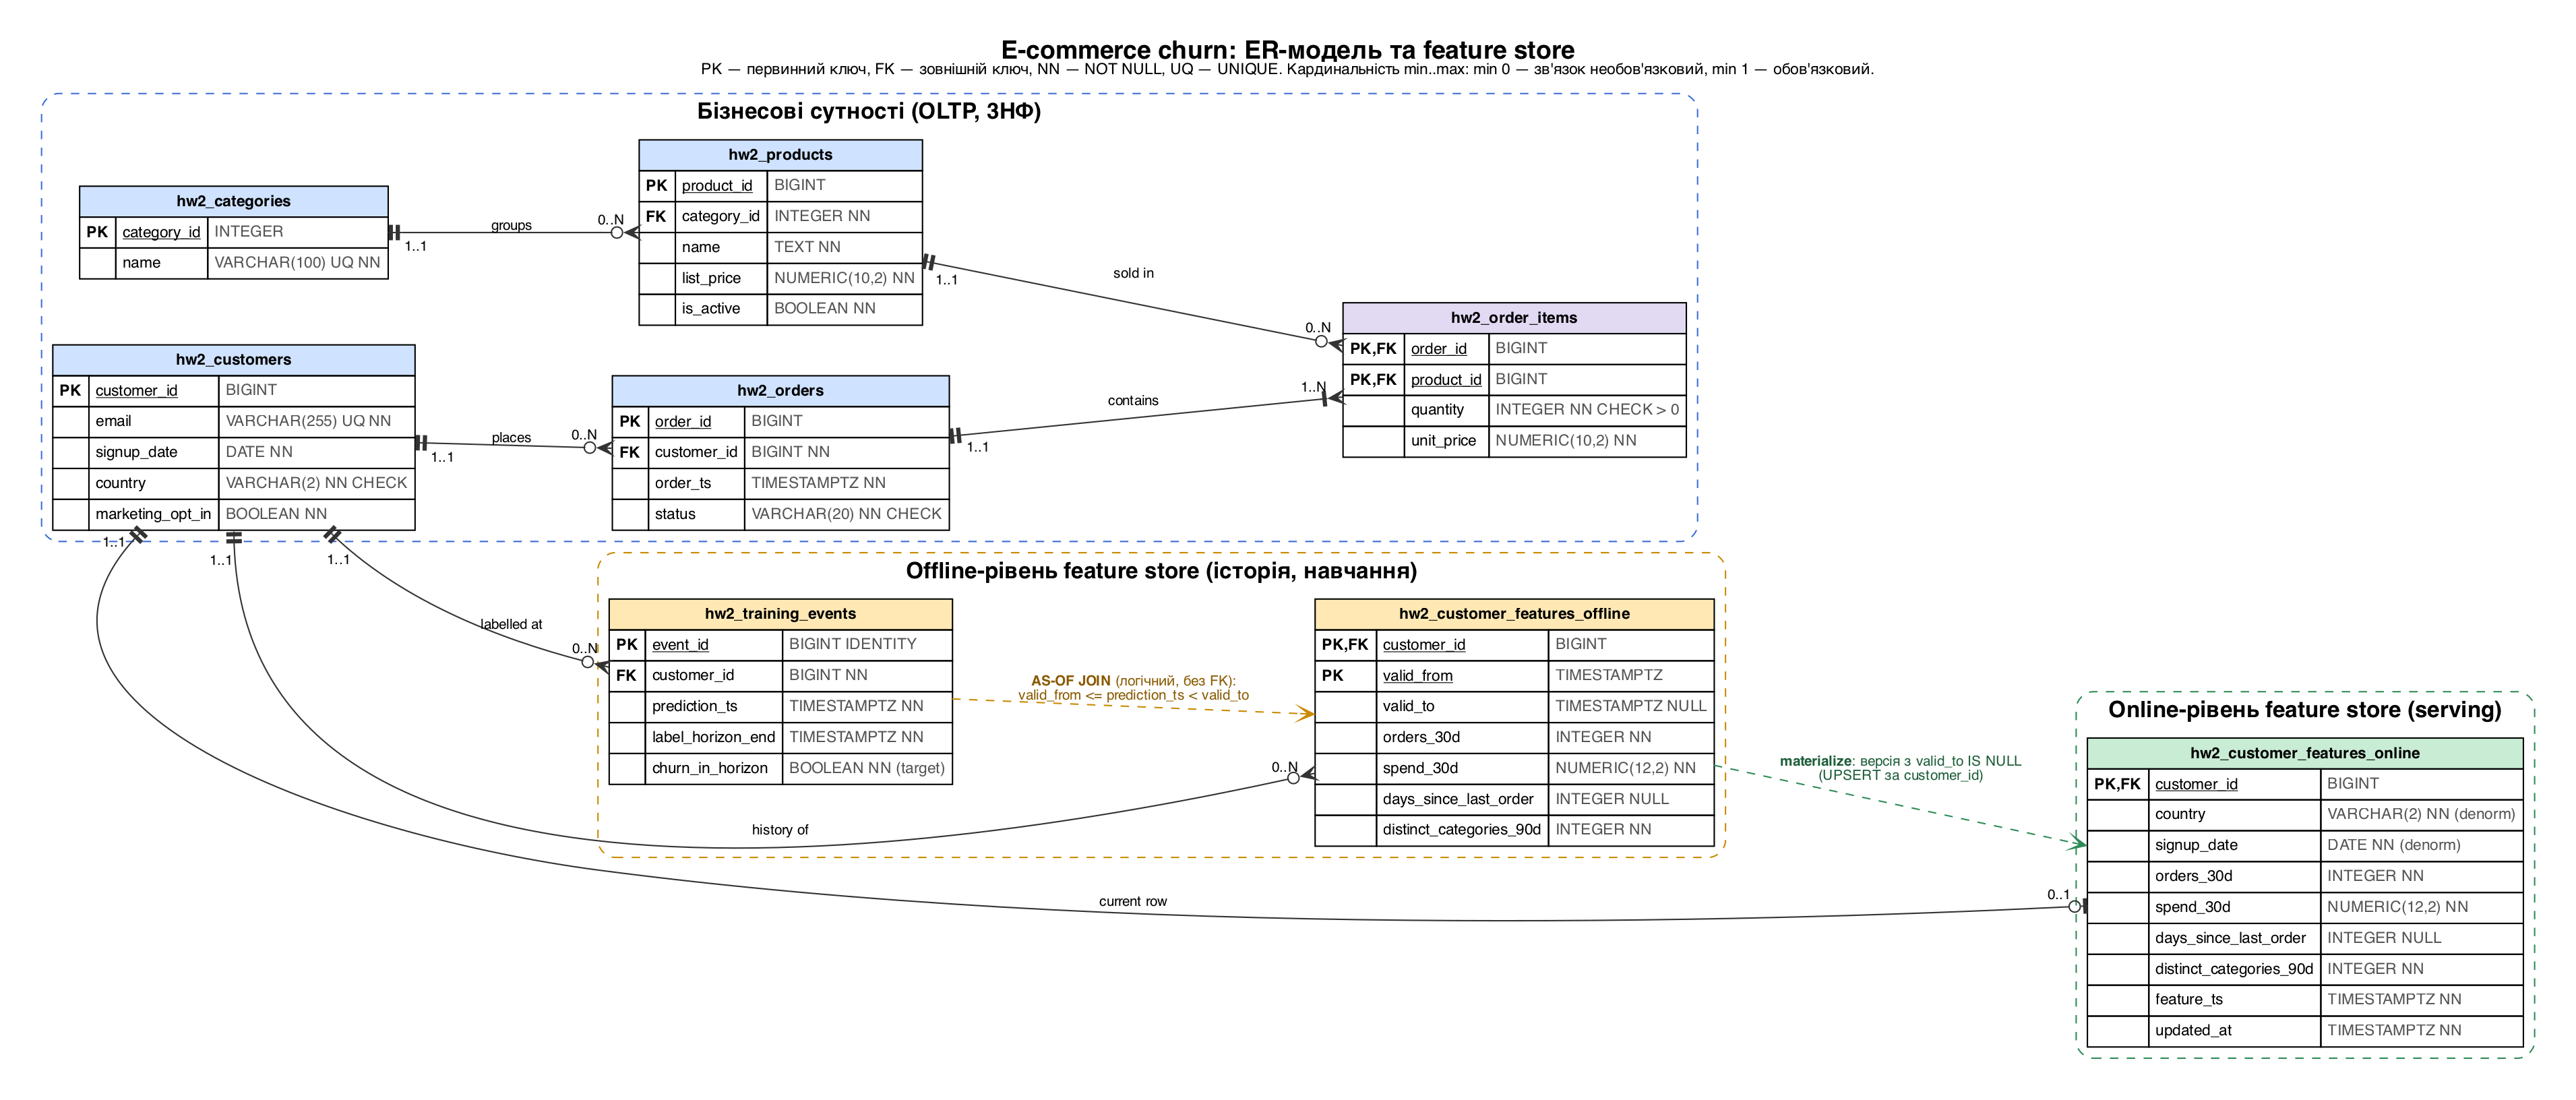

### Кардинальності та обов'язковість зв'язків

Нотація `min..max`: `min = 0` — зв'язок необов'язковий, `min = 1` — обов'язковий.

| Батьківська таблиця (PK) | Дочірня таблиця (FK) | Кардинальність | Зміст |
|---|---|---|---|
| `hw2_customers` | `hw2_orders` | 1..1 — 0..N | замовлення завжди має клієнта; клієнт може ще нічого не купити |
| `hw2_orders` | `hw2_order_items` | 1..1 — 1..N | позиція належить одному замовленню; замовлення має хоча б одну позицію (бізнес-правило) |
| `hw2_products` | `hw2_order_items` | 1..1 — 0..N | товар може ще жодного разу не продаватися |
| `hw2_categories` | `hw2_products` | 1..1 — 0..N | товар обов'язково має категорію |
| `hw2_customers` | `hw2_customer_features_offline` | 1..1 — 0..N | історія версій ознак клієнта (може бути порожньою для нового клієнта) |
| `hw2_customers` | `hw2_training_events` | 1..1 — 0..N | точки прогнозу з міткою |
| `hw2_customers` | `hw2_customer_features_online` | 1..1 — 0..1 | не більше одного поточного рядка на клієнта |

### Зв'язок N:M

У домені є природний зв'язок **N:M між замовленнями й товарами**: одне замовлення містить багато товарів,
один товар входить у багато замовлень. Його реалізовано bridge-таблицею `hw2_order_items` зі складеним
PK `(order_id, product_id)` і власними атрибутами зв'язку `quantity`, `unit_price` (ціна на момент покупки).
Зв'язок «клієнт ↔ товар» теж є N:M, але він похідний (через `orders` → `order_items`), тому окрема
таблиця для нього не потрібна.

## Завдання 2. DDL у PostgreSQL 16

- `DROP TABLE IF EXISTS ... CASCADE` на початку робить повторний запуск відтворюваним.
- `PRIMARY KEY` у кожній таблиці, `FOREIGN KEY` для всіх зв'язків, `NOT NULL` для обов'язкових колонок.
- Доменні `CHECK`: формат коду країни, допустимі статуси замовлення, невід'ємні кількості/суми, `quantity > 0`.
- Temporal `CHECK (valid_to IS NULL OR valid_to > valid_from)` в історичній feature-таблиці.
- Індекси під основні access patterns:
  - `hw2_idx_customer_features_asof (customer_id, valid_from DESC)` — AS-OF lookup ознак клієнта;
  - `hw2_uq_customer_features_current` — частковий унікальний індекс: не більше однієї поточної версії (`valid_to IS NULL`) на клієнта;
  - `hw2_idx_orders_customer_ts (customer_id, order_ts)` — вибірка замовлень клієнта за часовим вікном під час розрахунку ознак.

In [ ]:
%%sql
SET TIME ZONE 'UTC';

DROP TABLE IF EXISTS
    hw2_customer_features_online,
    hw2_training_events,
    hw2_customer_features_offline,
    hw2_order_items,
    hw2_orders,
    hw2_products,
    hw2_categories,
    hw2_customers
CASCADE;

-- =========================================================
-- Бізнесові сутності (нормалізовані, 3НФ)
-- =========================================================

CREATE TABLE hw2_customers (
    customer_id      BIGINT       PRIMARY KEY,
    email            VARCHAR(255) NOT NULL UNIQUE,
    signup_date      DATE         NOT NULL,
    country          VARCHAR(2)   NOT NULL
        CHECK (country ~ '^[A-Z]{2}$'),
    marketing_opt_in BOOLEAN      NOT NULL DEFAULT FALSE
);

CREATE TABLE hw2_categories (
    category_id INTEGER      PRIMARY KEY,
    name        VARCHAR(100) NOT NULL UNIQUE
);

CREATE TABLE hw2_products (
    product_id  BIGINT        PRIMARY KEY,
    category_id INTEGER       NOT NULL
        REFERENCES hw2_categories(category_id),
    name        TEXT          NOT NULL,
    list_price  NUMERIC(10, 2) NOT NULL
        CHECK (list_price >= 0),
    is_active   BOOLEAN       NOT NULL DEFAULT TRUE
);

CREATE TABLE hw2_orders (
    order_id    BIGINT      PRIMARY KEY,
    customer_id BIGINT      NOT NULL
        REFERENCES hw2_customers(customer_id),
    order_ts    TIMESTAMPTZ NOT NULL,
    status      VARCHAR(20) NOT NULL
        CHECK (status IN ('paid', 'shipped', 'delivered', 'cancelled', 'returned'))
);

-- Bridge-таблиця для природного зв'язку N:M orders <-> products
CREATE TABLE hw2_order_items (
    order_id   BIGINT         NOT NULL
        REFERENCES hw2_orders(order_id) ON DELETE CASCADE,
    product_id BIGINT         NOT NULL
        REFERENCES hw2_products(product_id),
    quantity   INTEGER        NOT NULL
        CHECK (quantity > 0),
    unit_price NUMERIC(10, 2) NOT NULL
        CHECK (unit_price >= 0),

    PRIMARY KEY (order_id, product_id)
);

-- Основний access pattern для розрахунку ознак:
-- замовлення конкретного клієнта за часовим вікном
CREATE INDEX hw2_idx_orders_customer_ts
    ON hw2_orders (customer_id, order_ts);

-- =========================================================
-- Offline-рівень feature store: історія версій ознак
-- Кожна версія чинна на інтервалі [valid_from, valid_to)
-- =========================================================

CREATE TABLE hw2_customer_features_offline (
    customer_id             BIGINT         NOT NULL
        REFERENCES hw2_customers(customer_id),
    valid_from              TIMESTAMPTZ    NOT NULL,
    valid_to                TIMESTAMPTZ,
    orders_30d              INTEGER        NOT NULL
        CHECK (orders_30d >= 0),
    spend_30d               NUMERIC(12, 2) NOT NULL
        CHECK (spend_30d >= 0),
    days_since_last_order   INTEGER
        CHECK (days_since_last_order IS NULL OR days_since_last_order >= 0),
    distinct_categories_90d INTEGER        NOT NULL
        CHECK (distinct_categories_90d >= 0),

    PRIMARY KEY (customer_id, valid_from),

    CHECK (valid_to IS NULL OR valid_to > valid_from)
);

-- AS-OF lookup: остання версія з valid_from <= ts для клієнта
CREATE INDEX hw2_idx_customer_features_asof
    ON hw2_customer_features_offline (customer_id, valid_from DESC);

-- Для кожного клієнта може існувати не більше однієї поточної версії
CREATE UNIQUE INDEX hw2_uq_customer_features_current
    ON hw2_customer_features_offline (customer_id)
    WHERE valid_to IS NULL;

-- =========================================================
-- Training events: момент прогнозу + цільова змінна
-- =========================================================

CREATE TABLE hw2_training_events (
    event_id          BIGINT      GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY,
    customer_id       BIGINT      NOT NULL
        REFERENCES hw2_customers(customer_id),
    prediction_ts     TIMESTAMPTZ NOT NULL,
    label_horizon_end TIMESTAMPTZ NOT NULL,
    churn_in_horizon  BOOLEAN     NOT NULL,

    UNIQUE (customer_id, prediction_ts),
    CHECK (label_horizon_end > prediction_ts)
);

-- =========================================================
-- Online-рівень feature store: один денормалізований рядок
-- на клієнта (лише поточні значення) для швидкого lookup
-- =========================================================

CREATE TABLE hw2_customer_features_online (
    customer_id             BIGINT         PRIMARY KEY
        REFERENCES hw2_customers(customer_id),
    country                 VARCHAR(2)     NOT NULL,
    signup_date             DATE           NOT NULL,
    orders_30d              INTEGER        NOT NULL
        CHECK (orders_30d >= 0),
    spend_30d               NUMERIC(12, 2) NOT NULL
        CHECK (spend_30d >= 0),
    days_since_last_order   INTEGER
        CHECK (days_since_last_order IS NULL OR days_since_last_order >= 0),
    distinct_categories_90d INTEGER        NOT NULL
        CHECK (distinct_categories_90d >= 0),
    feature_ts              TIMESTAMPTZ    NOT NULL,
    updated_at              TIMESTAMPTZ    NOT NULL DEFAULT CURRENT_TIMESTAMP
);

In [ ]:
%%sql
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
  AND table_name LIKE 'hw2\_%'
ORDER BY table_name;

## Завдання 3. Нормалізація

**Таблиці у 3НФ.** `hw2_customers`, `hw2_categories`, `hw2_products`, `hw2_orders`, `hw2_order_items` і
`hw2_customer_features_offline` перебувають у 3НФ: значення атомарні, кожна таблиця має PK, а неключові атрибути
залежать від усього ключа і тільки від нього — часткових і транзитивних залежностей немає.

**Функціональні залежності, враховані під час декомпозиції:**
- `customer_id → email, signup_date, country, marketing_opt_in`
- `category_id → name`; `product_id → category_id, name, list_price, is_active`
- `order_id → customer_id, order_ts, status`
- `(order_id, product_id) → quantity, unit_price`
- `(customer_id, valid_from) → valid_to, orders_30d, spend_30d, days_since_last_order, distinct_categories_90d`

Назву категорії винесено в окрему таблицю, щоб прибрати транзитивну залежність `product_id → category_id → category_name`.
Суму замовлення не зберігаємо — вона обчислюється з позицій. `unit_price` не дублює `list_price`: це ціна на момент
покупки, вона залежить від позиції замовлення, а не від товару.

**Свідома денормалізація.** `hw2_customer_features_online` містить лише поточну версію ознак і копії `country`,
`signup_date` з `hw2_customers`. Read pattern — lookup одного рядка за `customer_id` під час інференсу з низькою
latency: один index scan за PK, без JOIN і без часових фільтрів.

**Ризик неузгодженості.** Якщо з'явиться нова версія ознак або клієнт змінить країну, online-рядок буде застарілим
до наступного оновлення.

**Оновлення.** Батч-джоба бере з offline-таблиці версію з `valid_to IS NULL`, приєднує атрибути клієнта й виконує
`INSERT ... ON CONFLICT (customer_id) DO UPDATE` (розділ 5). `feature_ts` = `valid_from` версії дає змогу контролювати
свіжість, а окремий запит рахує розбіжності між рівнями.

## Завдання 4. Point-in-Time correctness

### 4.1. Тестові дані

- 12 temporal-версій ознак для 4 клієнтів (`customer_id = 42` — 4 послідовні версії, `1` і `2` — по 3, `3` — 2);
- усі часові літерали — `TIMESTAMPTZ` з явним `+00` (UTC);
- версії одного клієнта йдуть встик: `valid_to` попередньої = `valid_from` наступної, тому інтервали не перекриваються й не мають «дір»;
- 9 training events; серед них є подія рівно на межі версій (`2025-01-15 00:00:00+00`) і подія до появи першої версії ознак.

In [ ]:
%%sql
INSERT INTO hw2_customers
    (customer_id, email, signup_date, country, marketing_opt_in)
VALUES
    (1,  'anna@example.com',  DATE '2024-01-10', 'UA', TRUE),
    (2,  'piotr@example.com', DATE '2024-02-20', 'PL', FALSE),
    (3,  'olena@example.com', DATE '2024-05-05', 'UA', TRUE),
    (42, 'max@example.com',   DATE '2024-03-15', 'DE', FALSE);

INSERT INTO hw2_categories (category_id, name)
VALUES
    (1, 'Electronics'),
    (2, 'Books'),
    (3, 'Home');

INSERT INTO hw2_products (product_id, category_id, name, list_price, is_active)
VALUES
    (101, 1, 'Wireless headphones', 79.99, TRUE),
    (102, 1, 'USB-C charger',       25.00, TRUE),
    (201, 2, 'SQL for Data Science', 39.90, TRUE),
    (202, 2, 'Novel "Kobzar"',      15.50, TRUE),
    (301, 3, 'Desk lamp',           49.00, FALSE);

INSERT INTO hw2_orders (order_id, customer_id, order_ts, status)
VALUES
    (1001, 42, TIMESTAMPTZ '2024-09-19 14:20:00+00', 'delivered'),
    (1002, 42, TIMESTAMPTZ '2024-10-27 09:05:00+00', 'delivered'),
    (1003, 42, TIMESTAMPTZ '2024-12-14 18:40:00+00', 'delivered'),
    (1004, 1,  TIMESTAMPTZ '2024-11-13 11:00:00+00', 'delivered'),
    (1005, 1,  TIMESTAMPTZ '2024-12-23 16:30:00+00', 'shipped'),
    (1006, 2,  TIMESTAMPTZ '2024-10-11 08:15:00+00', 'delivered'),
    (1007, 3,  TIMESTAMPTZ '2024-10-26 19:45:00+00', 'delivered'),
    (1008, 3,  TIMESTAMPTZ '2024-12-17 12:10:00+00', 'returned');

INSERT INTO hw2_order_items (order_id, product_id, quantity, unit_price)
VALUES
    (1001, 101, 1, 79.99),
    (1002, 102, 1, 25.00),
    (1002, 202, 1, 15.50),
    (1003, 201, 2, 39.90),
    (1003, 301, 1, 45.00),
    (1004, 101, 1, 74.99),
    (1004, 201, 1, 39.90),
    (1005, 202, 3, 15.50),
    (1006, 202, 1, 15.50),
    (1007, 201, 1, 39.90),
    (1007, 301, 1, 49.00),
    (1008, 102, 2, 25.00);

-- Історія ознак: 12 temporal-версій для 4 клієнтів.
-- Для customer_id = 42 — 4 послідовні версії, для 1 і 2 — по 3, для 3 — 2.
-- Кожна наступна версія починається рівно там, де закінчується попередня.
INSERT INTO hw2_customer_features_offline
    (customer_id, valid_from, valid_to,
     orders_30d, spend_30d, days_since_last_order, distinct_categories_90d)
VALUES
    (42, TIMESTAMPTZ '2024-10-01 00:00:00+00', TIMESTAMPTZ '2024-11-01 00:00:00+00', 1,  79.99, 12, 1),
    (42, TIMESTAMPTZ '2024-11-01 00:00:00+00', TIMESTAMPTZ '2024-12-15 00:00:00+00', 2, 100.00,  5, 2),
    (42, TIMESTAMPTZ '2024-12-15 00:00:00+00', TIMESTAMPTZ '2025-01-15 00:00:00+00', 5, 200.00,  1, 3),
    (42, TIMESTAMPTZ '2025-01-15 00:00:00+00', NULL,                                  0,   0.00, 32, 2),

    (1,  TIMESTAMPTZ '2024-10-01 00:00:00+00', TIMESTAMPTZ '2024-11-15 00:00:00+00', 3, 120.50,  4, 2),
    (1,  TIMESTAMPTZ '2024-11-15 00:00:00+00', TIMESTAMPTZ '2025-01-01 00:00:00+00', 4, 180.00,  2, 3),
    (1,  TIMESTAMPTZ '2025-01-01 00:00:00+00', NULL,                                  2,  95.00,  9, 2),

    (2,  TIMESTAMPTZ '2024-10-15 00:00:00+00', TIMESTAMPTZ '2024-12-01 00:00:00+00', 1,  15.50, 20, 1),
    (2,  TIMESTAMPTZ '2024-12-01 00:00:00+00', TIMESTAMPTZ '2025-01-10 00:00:00+00', 0,   0.00, 50, 1),
    (2,  TIMESTAMPTZ '2025-01-10 00:00:00+00', NULL,                                  0,   0.00, 90, 0),

    (3,  TIMESTAMPTZ '2024-11-01 00:00:00+00', TIMESTAMPTZ '2024-12-20 00:00:00+00', 2,  88.90,  6, 2),
    (3,  TIMESTAMPTZ '2024-12-20 00:00:00+00', NULL,                                  3, 140.40,  3, 3);

-- Training events: момент прогнозу, горизонт 30 днів і мітка churn.
INSERT INTO hw2_training_events
    (customer_id, prediction_ts, label_horizon_end, churn_in_horizon)
VALUES
    (42, TIMESTAMPTZ '2024-12-10 10:00:00+00', TIMESTAMPTZ '2025-01-09 10:00:00+00', FALSE),
    (42, TIMESTAMPTZ '2024-12-20 10:00:00+00', TIMESTAMPTZ '2025-01-19 10:00:00+00', TRUE),
    (42, TIMESTAMPTZ '2025-01-15 00:00:00+00', TIMESTAMPTZ '2025-02-14 00:00:00+00', TRUE),
    (1,  TIMESTAMPTZ '2024-12-01 12:00:00+00', TIMESTAMPTZ '2024-12-31 12:00:00+00', FALSE),
    (1,  TIMESTAMPTZ '2025-01-05 09:00:00+00', TIMESTAMPTZ '2025-02-04 09:00:00+00', FALSE),
    (2,  TIMESTAMPTZ '2024-11-20 08:00:00+00', TIMESTAMPTZ '2024-12-20 08:00:00+00', FALSE),
    (2,  TIMESTAMPTZ '2025-01-05 08:00:00+00', TIMESTAMPTZ '2025-02-04 08:00:00+00', TRUE),
    (3,  TIMESTAMPTZ '2024-10-20 00:00:00+00', TIMESTAMPTZ '2024-11-19 00:00:00+00', FALSE),
    (3,  TIMESTAMPTZ '2024-12-01 18:00:00+00', TIMESTAMPTZ '2024-12-31 18:00:00+00', FALSE);

### 4.2. Поява нової версії ознак (SCD Type 2) в одній транзакції

Нова версія додається двома кроками: закрити поточну (`valid_to = new_ts`) і вставити нову (`valid_from = new_ts`,
`valid_to = NULL`). Обидва кроки виконуються **атомарно** (`engine.begin()` = `BEGIN ... COMMIT`): якщо вставка
не вдасться, закриття старої версії теж відкотиться, і клієнт не залишиться без поточної версії.
Після цього кроку в історичній таблиці 13 рядків, у клієнта `3` — 3 версії.

In [ ]:
new_ts = "2025-01-20 00:00:00+00"

with engine.begin() as conn:  # BEGIN ... COMMIT (або ROLLBACK при помилці)
    conn.execute(text("""
        UPDATE hw2_customer_features_offline
        SET valid_to = CAST(:ts AS timestamptz)
        WHERE customer_id = 3
          AND valid_to IS NULL
    """), {"ts": new_ts})
    conn.execute(text("""
        INSERT INTO hw2_customer_features_offline
            (customer_id, valid_from, valid_to,
             orders_30d, spend_30d, days_since_last_order, distinct_categories_90d)
        VALUES (3, CAST(:ts AS timestamptz), NULL, 1, 50.00, 34, 1)
    """), {"ts": new_ts})
print("Нову версію для customer_id = 3 додано.")

In [ ]:
%%sql
SELECT customer_id,
       COUNT(*)                          AS versions,
       MIN(valid_from)                   AS first_version_from,
       COUNT(*) FILTER (WHERE valid_to IS NULL) AS current_versions
FROM hw2_customer_features_offline
GROUP BY customer_id
ORDER BY customer_id;

### 4.3. AS-OF SELECT №1: ознаки клієнта 42 станом на `2024-12-10 10:00:00+00`

Очікувано: версія `[2024-11-01, 2024-12-15)` з `orders_30d = 2`. Версія, що починається 2024-12-15,
на момент прогнозу ще не існувала й не повинна потрапити в результат.

In [ ]:
%%sql
SELECT customer_id, orders_30d, spend_30d, days_since_last_order,
       distinct_categories_90d, valid_from, valid_to
FROM hw2_customer_features_offline
WHERE customer_id = 42
  AND valid_from <= TIMESTAMPTZ '2024-12-10 10:00:00+00'
  AND (valid_to > TIMESTAMPTZ '2024-12-10 10:00:00+00' OR valid_to IS NULL);

### 4.4. AS-OF SELECT №2: момент рівно на межі версій `2025-01-15 00:00:00+00`

Інтервали напіввідкриті `[valid_from, valid_to)`: момент межі належить **лише новій** версії
(`valid_from = 2025-01-15`, `orders_30d = 0`), а стара версія з `valid_to = 2025-01-15` уже не чинна.
Тому результат — рівно один рядок.

In [ ]:
%%sql
SELECT customer_id, orders_30d, spend_30d, days_since_last_order,
       distinct_categories_90d, valid_from, valid_to
FROM hw2_customer_features_offline
WHERE customer_id = 42
  AND valid_from <= TIMESTAMPTZ '2025-01-15 00:00:00+00'
  AND (valid_to > TIMESTAMPTZ '2025-01-15 00:00:00+00' OR valid_to IS NULL);

### 4.5. AS-OF SELECT №3: зріз ознак усіх клієнтів станом на `2024-12-20 10:00:00+00`

Такий point-in-time snapshot потрібен, наприклад, для batch-скорингу на історичну дату.
Для клієнта 3 має повернутися версія, що почалася рівно 2024-12-20 00:00.

In [ ]:
%%sql
SELECT c.customer_id, c.country,
       f.orders_30d, f.spend_30d, f.days_since_last_order,
       f.distinct_categories_90d, f.valid_from, f.valid_to
FROM hw2_customers AS c
LEFT JOIN hw2_customer_features_offline AS f
       ON f.customer_id = c.customer_id
      AND f.valid_from <= TIMESTAMPTZ '2024-12-20 10:00:00+00'
      AND (f.valid_to > TIMESTAMPTZ '2024-12-20 10:00:00+00' OR f.valid_to IS NULL)
ORDER BY c.customer_id;

### 4.6. AS-OF JOIN: формування training data за `prediction_ts`

Кожен training event отримує лише ту версію ознак, яка була чинною на його `prediction_ts`.
`LEFT JOIN` зберігає подію навіть тоді, коли ознак ще не існувало (клієнт 3 на 2024-10-20) —
такі рядки з `NULL`-ознаками видно одразу, і їх можна свідомо відфільтрувати, а не втратити непомітно.

In [ ]:
%%sql
SELECT e.event_id,
       e.customer_id,
       e.prediction_ts,
       e.label_horizon_end,
       e.churn_in_horizon,
       f.orders_30d,
       f.spend_30d,
       f.days_since_last_order,
       f.distinct_categories_90d,
       f.valid_from AS feature_valid_from
FROM hw2_training_events AS e
LEFT JOIN hw2_customer_features_offline AS f
       ON f.customer_id = e.customer_id
      AND f.valid_from <= e.prediction_ts
      AND (f.valid_to > e.prediction_ts OR f.valid_to IS NULL)
ORDER BY e.event_id;

### 4.7. Контроль часових інтервалів

1. Перевірка перекривних версій для одного `customer_id` — **має повернути 0 рядків**.
2. Автоматичні перевірки (`assert`): немає `valid_to <= valid_from`, немає перекриттів,
   AS-OF JOIN не розмножує training events, жодна приєднана версія не почалася після `prediction_ts`.

In [ ]:
%%sql
SELECT a.customer_id,
       a.valid_from AS a_from, a.valid_to AS a_to,
       b.valid_from AS b_from, b.valid_to AS b_to
FROM hw2_customer_features_offline AS a
JOIN hw2_customer_features_offline AS b
  ON a.customer_id = b.customer_id
 AND a.valid_from < COALESCE(b.valid_to, 'infinity'::timestamptz)
 AND b.valid_from < COALESCE(a.valid_to, 'infinity'::timestamptz)
 AND a.valid_from < b.valid_from;

In [ ]:
checks = {
    "перекривні версії": """
        SELECT COUNT(*)
        FROM hw2_customer_features_offline a
        JOIN hw2_customer_features_offline b
          ON a.customer_id = b.customer_id
         AND a.valid_from < COALESCE(b.valid_to, 'infinity'::timestamptz)
         AND b.valid_from < COALESCE(a.valid_to, 'infinity'::timestamptz)
         AND a.valid_from < b.valid_from""",
    "valid_to <= valid_from": """
        SELECT COUNT(*) FROM hw2_customer_features_offline
        WHERE valid_to IS NOT NULL AND valid_to <= valid_from""",
    "події з >1 версією ознак": """
        SELECT COUNT(*) FROM (
            SELECT e.event_id
            FROM hw2_training_events e
            JOIN hw2_customer_features_offline f
              ON f.customer_id = e.customer_id
             AND f.valid_from <= e.prediction_ts
             AND (f.valid_to > e.prediction_ts OR f.valid_to IS NULL)
            GROUP BY e.event_id
            HAVING COUNT(*) > 1) t""",
    "ознаки з майбутнього в AS-OF JOIN": """
        SELECT COUNT(*)
        FROM hw2_training_events e
        JOIN hw2_customer_features_offline f
          ON f.customer_id = e.customer_id
         AND f.valid_from <= e.prediction_ts
         AND (f.valid_to > e.prediction_ts OR f.valid_to IS NULL)
        WHERE f.valid_from > e.prediction_ts""",
}

with engine.connect() as conn:
    n_hist = conn.execute(text("SELECT COUNT(*) FROM hw2_customer_features_offline")).scalar()
    n_events = conn.execute(text("SELECT COUNT(*) FROM hw2_training_events")).scalar()
    for name, q in checks.items():
        n = conn.execute(text(q)).scalar()
        print(f"{name:35s} -> {n}")
        assert n == 0, f"Перевірка не пройдена: {name}"

assert n_hist >= 10, "Потрібно щонайменше 10 історичних рядків"
print(f"\nІсторичних рядків: {n_hist}, training events: {n_events}. Усі перевірки пройдено.")

### 4.8. Чому простий JOIN лише за `customer_id` неприпустимий

Нижче — порівняння «наївного» JOIN і AS-OF JOIN. Наївний JOIN приєднує до кожної події **всі** версії
ознак клієнта, зокрема ті, що з'явилися після `prediction_ts`.

In [ ]:
%%sql
WITH naive AS (
    SELECT e.event_id, e.prediction_ts, f.valid_from
    FROM hw2_training_events AS e
    JOIN hw2_customer_features_offline AS f
      ON f.customer_id = e.customer_id
),
as_of AS (
    SELECT e.event_id
    FROM hw2_training_events AS e
    LEFT JOIN hw2_customer_features_offline AS f
           ON f.customer_id = e.customer_id
          AND f.valid_from <= e.prediction_ts
          AND (f.valid_to > e.prediction_ts OR f.valid_to IS NULL)
)
SELECT
    (SELECT COUNT(*) FROM hw2_training_events)                    AS training_events,
    (SELECT COUNT(*) FROM as_of)                                  AS rows_as_of_join,
    (SELECT COUNT(*) FROM naive)                                  AS rows_naive_join,
    (SELECT COUNT(*) FROM naive WHERE valid_from > prediction_ts) AS naive_rows_from_future;

**Висновок з таблиці вище.** AS-OF JOIN дає рівно по одному рядку на training event. Наївний JOIN повертає
значно більше рядків, і частина з них містить ознаки, обчислені **після** моменту прогнозу:

- **дублікати training examples**: одна подія потрапляє в датасет кілька разів з різними ознаками, що спотворює ваги й метрики;
- **data leakage**: для події клієнта 42 від `2024-12-10` у датасет потрапила б і версія від `2025-01-15`
  з `orders_30d = 0` та `days_since_last_order = 32`. Це фактично «підглядання» у майбутню неактивність, яка
  прямо корелює з міткою `churn_in_horizon`;
- **завищена якість моделі**: на навчанні й валідації модель «бачить» майбутнє і показує високі метрики, але в продакшені
  таких ознак на момент прогнозу немає, тож якість різко падає.

### 4.9. Пояснення умов AS-OF

1. **`valid_from <= prediction_ts`** — беремо лише версії, які вже існували на момент прогнозу.
   Версія, що почалася пізніше, містить інформацію з майбутнього.
2. **`valid_to > prediction_ts OR valid_to IS NULL`** — версія ще не була замінена на момент прогнозу. Строга
   нерівність виключає версію, яка закінчилася рівно в `prediction_ts`. `valid_to IS NULL` означає поточну (відкриту)
   версію; без цієї умови `NULL > ts` дає `NULL`, і поточна версія ніколи б не потрапляла в результат.
3. **Напіввідкриті інтервали `[valid_from, valid_to)`** — сусідні версії стикуються без перекриття й без «дір»:
   `valid_to` попередньої = `valid_from` наступної. Будь-який момент часу, зокрема точна межа
   (`2025-01-15 00:00:00+00` у запиті №2), належить рівно одній версії. Із закритими інтервалами `[a, b]` межа
   належала б двом версіям і створювала б дублікати.
4. **Без часового фільтра** до події потрапили б усі пізніші версії: майбутні значення `orders_30d`, `spend_30d`,
   `days_since_last_order`, які вже відображають поведінку клієнта в горизонті мітки, тобто саму відповідь (churn).

## 5. Online-рівень: матеріалізація з offline-джерела

Online-таблиця оновлюється батч-джобою: беремо поточну версію (`valid_to IS NULL`), приєднуємо атрибути клієнта
й виконуємо UPSERT. Умова `WHERE ... feature_ts <= EXCLUDED.feature_ts` не дає перезаписати свіжіші дані старішими,
тому повторний запуск ідемпотентний.

In [ ]:
%%sql
INSERT INTO hw2_customer_features_online
    (customer_id, country, signup_date,
     orders_30d, spend_30d, days_since_last_order, distinct_categories_90d,
     feature_ts, updated_at)
SELECT f.customer_id, c.country, c.signup_date,
       f.orders_30d, f.spend_30d, f.days_since_last_order, f.distinct_categories_90d,
       f.valid_from, CURRENT_TIMESTAMP
FROM hw2_customer_features_offline AS f
JOIN hw2_customers AS c ON c.customer_id = f.customer_id
WHERE f.valid_to IS NULL
ON CONFLICT (customer_id) DO UPDATE
SET country                 = EXCLUDED.country,
    signup_date             = EXCLUDED.signup_date,
    orders_30d              = EXCLUDED.orders_30d,
    spend_30d               = EXCLUDED.spend_30d,
    days_since_last_order   = EXCLUDED.days_since_last_order,
    distinct_categories_90d = EXCLUDED.distinct_categories_90d,
    feature_ts              = EXCLUDED.feature_ts,
    updated_at              = EXCLUDED.updated_at
WHERE hw2_customer_features_online.feature_ts <= EXCLUDED.feature_ts;

Online lookup під час інференсу — один рядок за PK, без JOIN і часових фільтрів:

In [ ]:
%%sql
SELECT customer_id, country, orders_30d, spend_30d, days_since_last_order,
       distinct_categories_90d, feature_ts
FROM hw2_customer_features_online
WHERE customer_id = 42;

Контроль узгодженості online ↔ offline (має повернути 0 розбіжностей):

In [ ]:
%%sql
SELECT COUNT(*) AS mismatches
FROM hw2_customer_features_offline AS f
LEFT JOIN hw2_customer_features_online AS o
       ON o.customer_id = f.customer_id
WHERE f.valid_to IS NULL
  AND (o.customer_id IS NULL
       OR o.feature_ts <> f.valid_from
       OR o.orders_30d <> f.orders_30d
       OR o.spend_30d <> f.spend_30d);

## Завдання 5. Reflection

**1. Що було найскладнішим.** Найбільше уваги потребувала point-in-time correctness. Треба було зафіксувати семантику
напіввідкритих інтервалів і гарантувати, що версії одного клієнта не перекриваються. У `pgserver` немає розширення
`btree_gist`, тому обмеження `EXCLUDE USING gist` недоступне. Натомість я поєднала temporal `CHECK`, частковий унікальний
індекс на поточну версію, зміну версії в одній транзакції та перевірочні запити з `assert`. Ще одна тонкість —
кардинальності: правило «замовлення має хоча б одну позицію» (1..N) не виражається через FK і залишається бізнес-правилом.

**2. Проєктні компроміси.** Бізнесові таблиці та offline-історію я нормалізувала до 3НФ. Offline-рівень читається
великими пакетами під час навчання, тому JOIN там прийнятні, а головне — коректність і відсутність дублювання. Online-рівень
навмисно денормалізований: один рядок поточних ознак плюс копії атрибутів клієнта, бо його читають точково за
`customer_id` з вимогою низької latency. Ціна цього рішення — потреба регулярно синхронізувати online з offline і контролювати розбіжності.

**3. Online-рівень при дуже великому навантаженні.** Я залишила б один денормалізований, попередньо матеріалізований рядок
на `customer_id`, але винесла б його в key-value сховище (Redis, DynamoDB) або поставила б кеш перед PostgreSQL.
Масштабувала б горизонтально (шардинг за `customer_id`, read-репліки), а батч-оновлення доповнила б потоковим. Свіжість
контролювала б через `feature_ts`, TTL і моніторинг затримки.

**4. Ризики еволюції схеми за шість місяців.** Перейменування чи видалення ознаки ламає запити й старі моделі. Зміна типу
(`INTEGER → NUMERIC`) або семантики (наприклад, `orders_30d` почне враховувати скасовані замовлення) небезпечна тим, що
назва лишається тією самою, а модель тихо деградує. Щоб цього уникнути, варто версіонувати ознаки (`orders_30d_v2`),
додавати колонки замість змінювати їх, проводити міграції через скрипти в git і вести feature registry з описом і
власником. Для кожної моделі слід зберігати перелік ознак і версію схеми, щоб старі моделі можна було підтримувати до виведення з експлуатації.

## Чек-лист

- [x] ER-діаграма з PK/FK, кардинальностями, offline- та online-рівнями; N:M через bridge-таблицю `hw2_order_items`
- [x] DDL виконується в PostgreSQL 16: PK, FK, NOT NULL, доменні CHECK, temporal CHECK, індекси
- [x] Історична feature-таблиця: 13 temporal-рядків для 4 клієнтів, 4 версії для `customer_id = 42`
- [x] Три AS-OF SELECT + AS-OF JOIN training events за `prediction_ts`
- [x] Перевірка перекривних інтервалів повертає 0 рядків
- [x] Notebook виконується від початку до кінця (Restart & Run All)